## Import libraries

In [1]:
!pip install -q requests torch bitsandbytes transformers sentencepiece accelerate

In [3]:
!pip install -U bitsandbytes

In [18]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch

from diffusers import DiffusionPipeline

## Login to hugging face

In [5]:
hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

## Use Llama 3.1 to generate synthetic data

### Extract the tokenizer from the pre-trained model

In [19]:
LLAMA = "meta-llama/Meta-Llama-3.1-8B-Instruct"
STABLE_DIFFUSION = "stabilityai/stable-diffusion-2"

### Write the system and user prompt

In [7]:
system_prompt = """You are a synthetic data generator. Your task is to generate tabular or text data according to the specifications provided to you.
Please politely reject a request if the requested data doesn't fit in to one of the before mentioned data categories.
Unless explicitly specified, the return format for tabular and text data should be json string, i.e, the user should be able to read it in using json.loads("tabular/text data").
"""

user_prompt_tabular = """Generate a table of 10 rows containing data about houses in Boston. The table should have the following columns:
- house_id - a unique identifier for each house. An integer column not containing any nulls.
- house_size - the size of the house in square feet. A float column containing some nulls. Make sure to inlcude some outliers.
- number_of_rooms - the number of rooms in the house. An integer column containing some nulls. Make sure to inlcude some outliers.
- number_of_bathrooms - the number of bathrooms in the house. An integer column containing some nulls. Make sure to inlcude some outliers.
- distance_from_public_transportation - an integer column representing the distance from public transportation in miles containing some nulls.
- year_built - the year the house was built. An integer column containing some nulls.
- house_price - The price of the house in $1000s. A float column containing some nulls. Make sure to inlcude some outliers.

An example of how synthetic data should be generated is as follows,
'{
  house_id:[1234, 5678],
  house_size:[1000, 750],
  number_of_rooms:[3, 4],
  number_of_bathrooms:[2, 3],
  distance_from_public_transportation:[5, 10],
  year_built:[1990, 2000],
  house_price:[200, 300]
}'
"""


In [8]:
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_prompt_tabular}
  ]

### Quantization config

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

### Generate tabular data

In [10]:
def generate_synthetic_tabular_data(model, messages):
  tokenizer = AutoTokenizer.from_pretrained(model)
  tokenizer.pad_token = tokenizer.eos_token
  inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True).to("cuda")
  streamer = TextStreamer(tokenizer)
  model = AutoModelForCausalLM.from_pretrained(model, device_map="auto", quantization_config=quant_config)
  outputs = model.generate(inputs, max_new_tokens=1000, streamer=streamer)
  del tokenizer, streamer, model, inputs #, outputs
  torch.cuda.empty_cache()
  return outputs

In [11]:
tabular_data = generate_synthetic_tabular_data(LLAMA, messages)

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are a synthetic data generator. Your task is to generate tabular, text and image data according to the specifications provided to you.
Please politely reject a request if the requested data doesn't fit in to one of the before mentioned categories. 
Unless explicitly specified, the return format for tabular and text data should be json string, i.e, the user should be able to read it in using json.loads("tabular/text data"). 
For Image data, please return the generated images as base64 strings, i.e, the user should be able to load it as an image using PIL.Image.open(BytesIO("image_data"))<|eot_id|><|start_header_id|>user<|end_header_id|>

Generate a table of 10 rows containing data about houses in Boston. The table should have the following columns:
- house_id - a unique identifier for each house. An integer column not containing any nulls. 
- house_size - the s

## Generate Image data

Image generation tasks don't require a system and user prompt.
Only a single text prompt would be needed. One prompt generates one image. Therefore, N prompts would need to be passed, to get a dataset of size N.

In [23]:
user_prompt_image = ["a cat", "a cat", "a dog", "a dog"]

In [26]:
def generate_synthetic_images(model, messages):

  image_gen = DiffusionPipeline.from_pretrained(
    model,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16"
    ).to("cuda")

  images = []
  for p in messages:
    image = image_gen(prompt=p).images[0]
    images.append(image)
  return images

In [27]:
images = generate_synthetic_images(STABLE_DIFFUSION, user_prompt_image)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

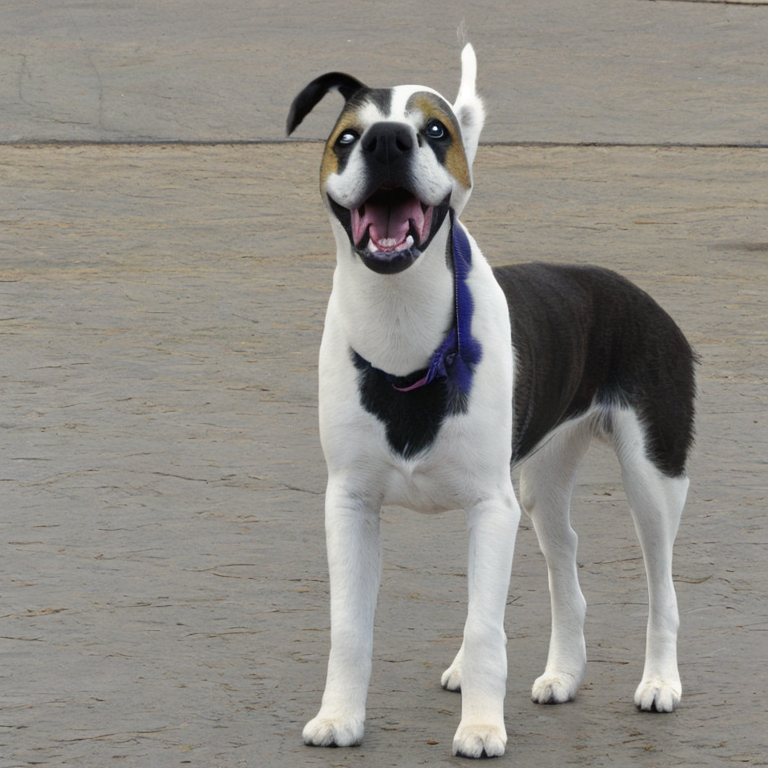

In [32]:
images[3]

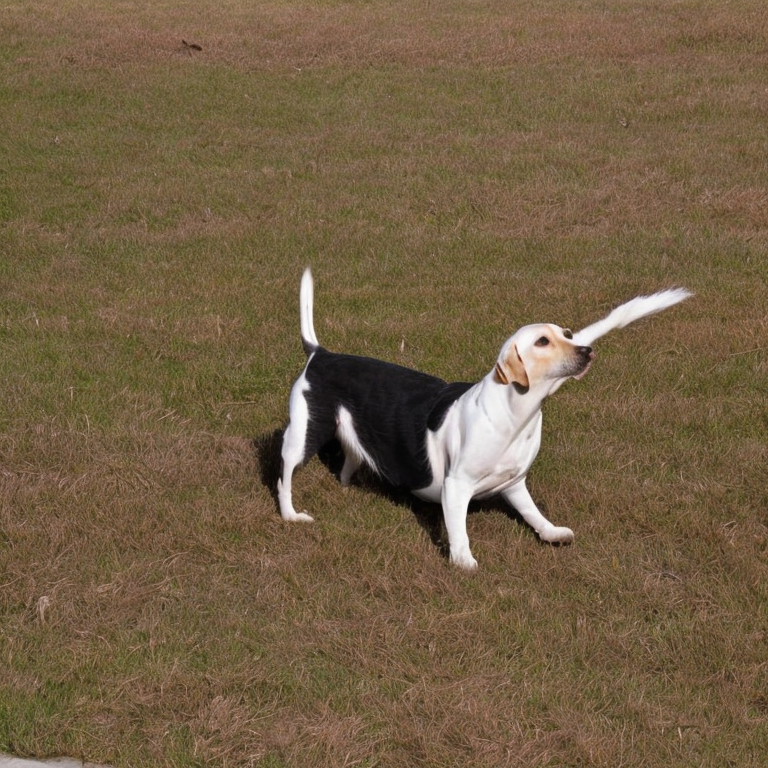

In [33]:
images[2]

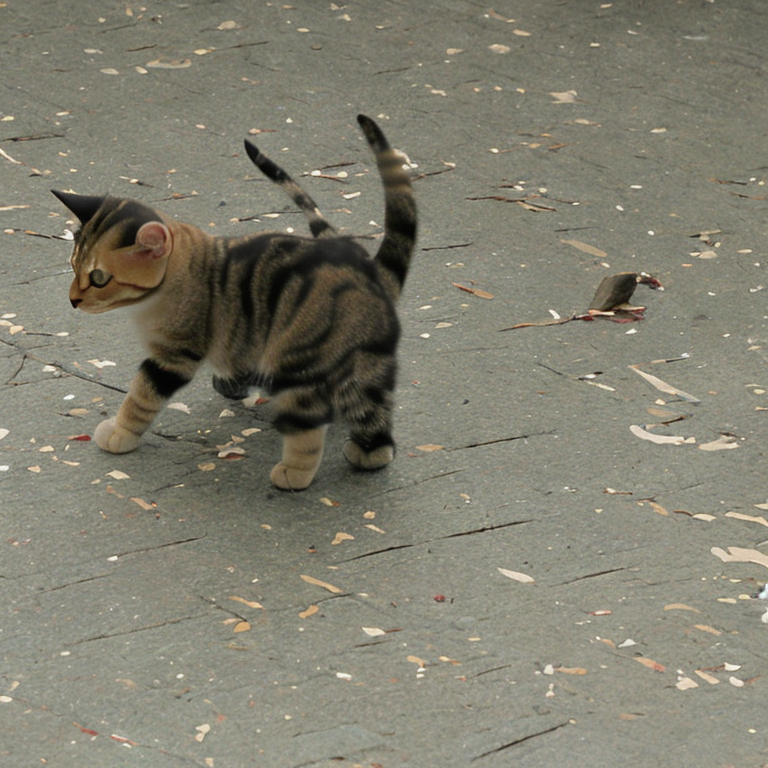

In [34]:
images[1]

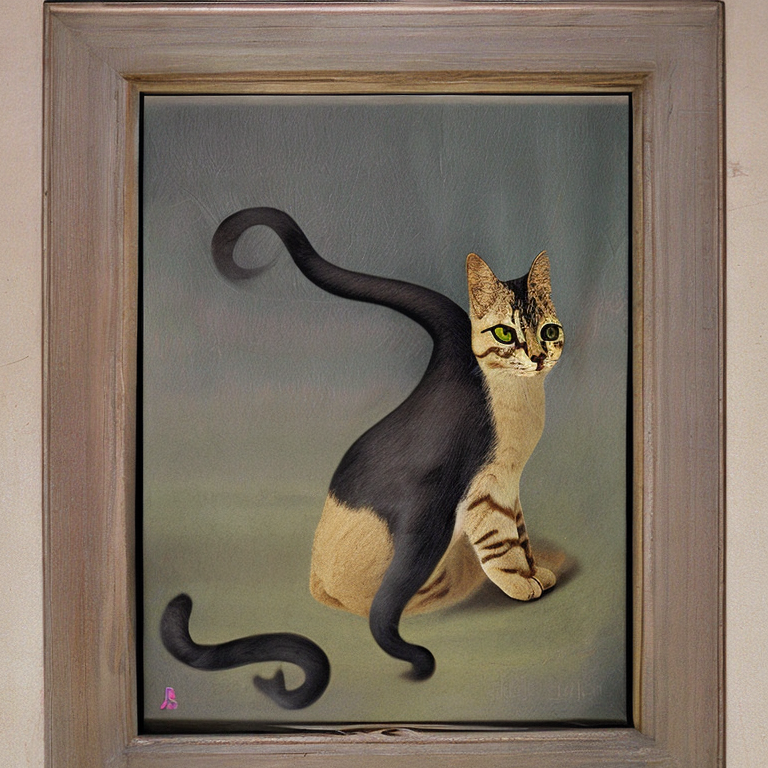

In [36]:
images[0]